# FX pairs: what a tree can express that a weighted sum cannot

[`06_linear`](06_linear.ipynb) established two things about this universe. The 20 pairs are
quotes between eight currencies, so the cross-section is dependent - a dollar move appears in
every pair with USD on one side, at the same moment, in the same direction - and a penalty
addresses the collinear feature set while doing nothing about that. Within those limits the
penalty sweep moved the ranking from the wrong side of zero to a thin margin above it.

Gradient boosting changes what can be represented, not what the cross-section is. A linear model
assigns one weight per feature and applies it everywhere; a tree splits on one feature inside a
region defined by another, so it can express "when the dollar is trending, rank on momentum;
otherwise rank on carry" without anyone constructing that column. Whether an exchange-rate cross
section rewards that is the question here, and it is a fair one: currency returns are widely
modelled as regime-dependent, and a regime is exactly a condition on one variable that changes
how another behaves.

Three dials control how far the model goes, and this notebook varies all three:

- **Capacity**, set by `num_leaves`: how many regions one tree may carve the feature space into,
  and therefore how fine a set of conditions it can express.
- **The loss function**, which decides what "got wrong" means. Squared error weights an
  observation by the square of its error; absolute error and Huber do not. Daily exchange-rate
  returns are less heavy-tailed than commodity or crypto returns, which makes this case study
  the useful control on whether the objective matters for the reason the tails suggest.
- **When to stop**, set by the number of trees. A boosted model has a meaningful state at every
  iteration, so each configuration is scored at ten points along its own training run.

**A checkpoint is part of a configuration, not a detail of how it was fitted.** Fifteen declared
configurations at ten checkpoints is 150 candidate models, and reporting the leading row of that
table as though it were one experiment would be reporting the maximum of 150 numbers.

**Learning objectives.** By the end of this notebook you will be able to:

- Read a declared gradient boosting grid and say what each configuration varies.
- Explain why a boosted model produces one result per checkpoint while a linear model produces
  one result in total, and what that implies for counting candidates.
- Read a learning curve of out-of-sample information coefficient against tree count, and say
  whether an apparent peak is a turning point or the highest of ten noisy readings.
- Say what a tree ensemble can represent that a penalized linear model cannot, and judge from
  the results whether this cross-section rewards it.
- Distinguish a model that ranks a dependent cross-section well from one that has found many
  independent facts.

**Book reference**: Chapter 12, Section 12.2 (GBM libraries) and Section 12.3 (how to tune a
boosted model). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run
log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) fitted the linear population this one is compared against.

**What it writes**: one training run per configuration and one complete validation prediction
set per configuration and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`13_backtest`](13_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared FX pairs gradient boosting population on the walk-forward folds."""

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABEL = "fwd_ret_1d"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = "fx_pairs-gbm-validation-v1"

In [3]:
study = open_study("fx_pairs", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which label, and which models

The label is the same one the linear notebook used: `fwd_ret_1d`, the return over the trading
day after the decision date. Keeping it fixed is what makes the two populations comparable -
the families differ, the target does not.

In [4]:
declared_labels(study, "gbm")

('fwd_ret_1d', 'fwd_ret_21d', 'fwd_ret_5d')

The menu at `config/training/{label}.yaml` lists 15 named configurations under `gbm:`, and each
resolves to a preset in `case_studies/config/lgb/`. The grid is a product of two axes:

- **Five capacity profiles.** `default` uses the library's own leaf count; the rest fix it at 7,
  15, 31 and 63. Leaf count is the direct control on how finely one tree may partition the
  feature space. It is the dial that decides whether a model can express a condition like "when
  the dollar is trending, rank on momentum; otherwise rank on carry" - a statement about one
  feature that only holds inside a region defined by another.
- **Three objectives.** `mse` minimizes squared error, `mae` absolute error, and `huber` behaves
  like squared error for small residuals and like absolute error beyond a threshold derived from
  each fold's own label spread.

Every configuration runs the same number of boosting iterations with the same learning rate, so
the grid isolates capacity and loss rather than confounding them with training length.

In [5]:
configs = load_model_configs(
    study,
    "gbm",
    labels=[LABEL],
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""gbm""","""fwd_ret_1d""","""default_mse""","""""","""objective=regression, seed=42"""
"""gbm""","""fwd_ret_1d""","""default_mae""","""""","""objective=regression_l1, seed=…"
"""gbm""","""fwd_ret_1d""","""default_huber""","""""","""objective=huber, seed=42"""
"""gbm""","""fwd_ret_1d""","""leaves_7_mse""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_1d""","""leaves_7_mae""","""""","""bagging_fraction=0.8, bagging_…"
…,…,…,…,…
"""gbm""","""fwd_ret_1d""","""leaves_31_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_1d""","""leaves_31_huber""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_1d""","""leaves_63_mse""","""""","""bagging_fraction=0.8, bagging_…"


## 2. Binding the declarations to the data

Resolving reads the label and feature files, computes the fold boundaries, works out the exact
rows each fit must predict, and turns any data-dependent parameter into the number it will use.
Huber's threshold is one of those: it is a fraction of the training labels' standard deviation,
so it is a different number on every fold and is resolved from that fold's own data.

Nothing is fitted here, so the plan can be inspected first. Four things to check:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** A row that
  differs is a configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is where this differs from the linear plan.** It is the number of training
  states each configuration will publish predictions for. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

In [6]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,i64,i64,i64,i64,i64,date,date
"""default_huber""",63,20,41260,8,10,2016-01-05,2023-12-28
"""default_mae""",63,20,41260,8,10,2016-01-05,2023-12-28
"""default_mse""",63,20,41260,8,10,2016-01-05,2023-12-28
"""leaves_15_huber""",63,20,41260,8,10,2016-01-05,2023-12-28
"""leaves_15_mae""",63,20,41260,8,10,2016-01-05,2023-12-28
…,…,…,…,…,…,…,…
"""leaves_63_mae""",63,20,41260,8,10,2016-01-05,2023-12-28
"""leaves_63_mse""",63,20,41260,8,10,2016-01-05,2023-12-28
"""leaves_7_huber""",63,20,41260,8,10,2016-01-05,2023-12-28


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. casts the design matrix to the precision LightGBM works in and leaves missing values in
   place - a tree routes a missing value down its own branch, so imputing a median here would
   hand the model an observation nobody made,
3. fits the declared number of boosting iterations,
4. predicts the fold's validation rows at each checkpoint, using only the trees built up to that
   iteration.

Step 4 is what makes one fit produce many results. The fold predictions are concatenated into
one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

Preparation happens once per fold and is shared by every configuration, because slicing the
window and cleaning the rows depends on the data and not on the model. The run walks folds on
the outside and configurations on the inside for the same reason: one prepared fold is held at a
time rather than the whole set.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [7]:
execution, population = run_model_population(study, resolved, population_name=POPULATION_NAME)

print(f"{len(execution.runs)} configurations fitted")
print(f"population {population.name}: {len(population.members)} prediction sets")

15 configurations fitted
population fx_pairs-gbm-validation-v1: 150 prediction sets


Re-running this notebook unchanged costs the time it takes to read the data. Every identity is
re-derived from the inputs, the registry already holds the matching rows, and the runner returns
the stored result rather than fitting again.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("fx_pairs", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "gbm", labels=["fwd_ret_1d"], config_names=["leaves_15_huber", "leaves_31_huber"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-gbm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu declares. To fit something new, add a preset at
`case_studies/config/lgb/leaves_127_huber.yaml` and list `leaves_127_huber` under `gbm:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per configuration and checkpoint. `ic_mean` is the **information coefficient**: on each
validation date, rank the pairs by the model's prediction, rank them by the return they went
on to earn, correlate the two rankings, and average that daily correlation over the validation
period.

The table is sorted by IC, and the top of it is the trap this notebook exists to describe. The
leading row is the maximum of 150 numbers. Reading it as the result of one experiment would
attribute to the model whatever the stopping point contributed, and the section below measures
how large that contribution is before anything is concluded from the ranking.

In [8]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("ic_mean", descending=True)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("gbm execution returned a partial prediction set")

full_days = int(catalog.get_column("ic_n_days").max())
catalog = catalog.with_columns(full_coverage=pl.col("ic_n_days") == full_days)

print(f"{catalog.height} candidate models: {catalog.n_unique('config_name')} configurations")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each")
catalog.select(
    "config_name",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(15)

150 candidate models: 15 configurations
at 10 checkpoints each


config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,i64,f64,f64,f64,bool
"""leaves_7_huber""",50,0.001529,0.028076,2063.0,true
"""leaves_7_mae""",500,0.001473,0.02638,2063.0,true
"""leaves_15_huber""",50,0.001431,0.028045,2063.0,true
"""default_huber""",100,0.001042,0.021789,2063.0,true
"""leaves_15_huber""",150,0.000616,0.028924,2063.0,true
…,…,…,…,…,…
"""leaves_31_mae""",500,0.000085,0.02434,2063.0,true
"""leaves_31_huber""",100,0.000078,0.02801,2063.0,true
"""leaves_31_huber""",50,0.00004,0.027549,2063.0,true


### What more trees do

Each line traces one configuration's out-of-sample IC as trees are added to it. This is the
figure the checkpoint dimension exists to produce, and it separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
without trend around zero never had anything to learn in the first place, and its highest point
is wherever the noise happened to peak. The difference matters, because both produce a
respectable-looking maximum.

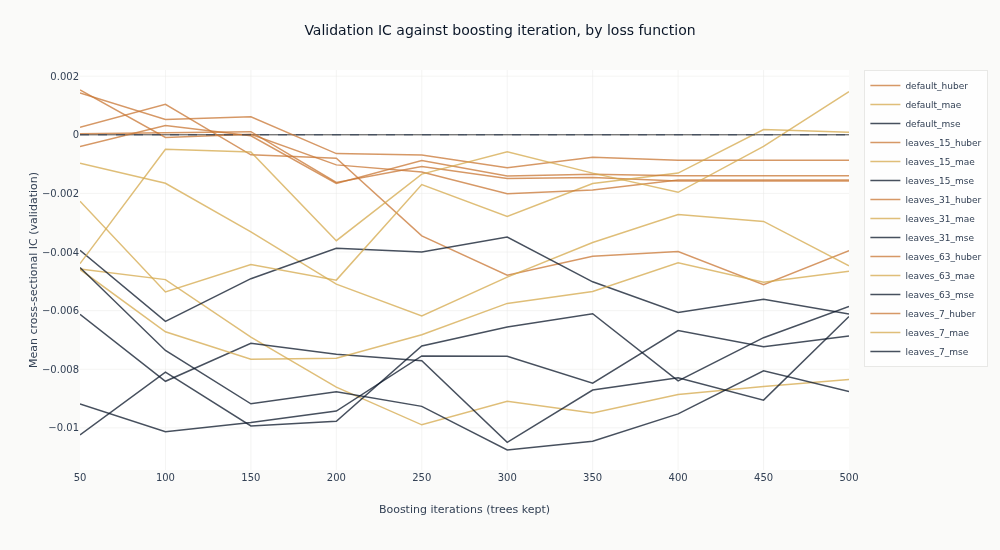

In [9]:
curves = catalog.filter("full_coverage").sort("config_name", "checkpoint_value")
objectives = {"mse": COLORS["blue"], "mae": COLORS["amber"], "huber": COLORS["copper"]}


def objective_of(name: str) -> str:
    """Read the loss function out of a declared configuration name."""
    return next((key for key in objectives if name.endswith(key)), "mse")


fig_curves = go.Figure()
for config_name in curves.get_column("config_name").unique(maintain_order=True):
    series = curves.filter(pl.col("config_name") == config_name)
    fig_curves.add_trace(
        go.Scatter(
            x=series.get_column("checkpoint_value").to_list(),
            y=series.get_column("ic_mean").to_list(),
            mode="lines",
            name=config_name,
            line=dict(color=objectives[objective_of(config_name)], width=1.5),
            opacity=0.75,
        )
    )
fig_curves.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_curves.update_layout(
    title="Validation IC against boosting iteration, by loss function",
    height=550,
    width=1000,
    margin=dict(t=70),
    legend=dict(font=dict(size=9)),
)
fig_curves.update_xaxes(title_text="Boosting iterations (trees kept)")
fig_curves.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_curves,
    "Line chart of mean validation information coefficient against boosting iteration, one line "
    "per configuration, coloured by loss function: blue for squared error, amber for absolute "
    "error, copper for Huber. A dashed line marks zero. Almost every line sits below it across "
    "the whole range, in a narrow band close to the line rather than far from it. The copper "
    "Huber lines run nearest to zero and the blue squared-error lines furthest below, and the "
    "lines wander up and down rather than rising to a common peak and falling away.",
)

### Whether the loss function is what separates them

The curves are coloured by objective because that is the axis with a mechanism behind it. If
heavy tails are steering the squared-error fits, the three colours should separate, and they
should separate more as trees are added, since each additional tree is fitted to the residuals
the previous ones left.

The chart below drops the checkpoint dimension by taking each configuration's final state, so
every configuration is compared at the same amount of training. That is the comparison that does
not require choosing anything after the fact.

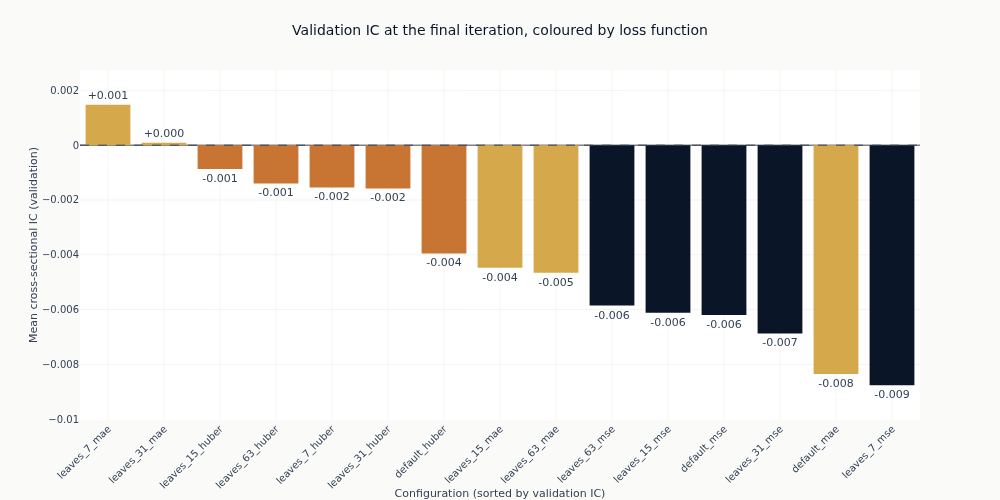

In [10]:
final_iteration = int(catalog.get_column("checkpoint_value").max())
final = (
    catalog.filter(pl.col("checkpoint_value") == final_iteration)
    .filter("full_coverage")
    .with_columns(objective=pl.col("config_name").map_elements(objective_of, return_dtype=pl.Utf8))
    .sort("ic_mean", descending=True)
)

fig_obj = go.Figure(
    go.Bar(
        x=final.get_column("config_name").to_list(),
        y=final.get_column("ic_mean").to_list(),
        marker_color=[objectives[value] for value in final.get_column("objective")],
        text=[f"{value:+.3f}" for value in final.get_column("ic_mean")],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_obj.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_obj.update_layout(
    title="Validation IC at the final iteration, coloured by loss function",
    height=500,
    width=1000,
    showlegend=False,
    margin=dict(t=70),
)
fig_obj.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_obj.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_obj,
    "Bar chart of mean validation information coefficient for every full-coverage configuration "
    "at its final boosting iteration, sorted descending and coloured by loss function, against a "
    "dashed zero line. Almost every bar hangs below the line, with one short bar just above it. "
    "Copper Huber bars are the shortest and sit at the left of the ranking, blue squared-error "
    "bars are the longest and sit at the right, and amber absolute-error bars fall between them "
    "and at both ends, so the loss function orders the configurations more than the leaf count "
    "does.",
)

### How much the checkpoint moves a configuration

One number per configuration: the range its IC covers across its own ten checkpoints. This is
the quantity that decides whether choosing a stopping point is a decision worth making carefully
or one being made by noise. A configuration whose IC varies more across its own training run
than the configurations vary among themselves is one where the checkpoint, not the model, is
doing the ranking.

In [11]:
spread = (
    curves.group_by("config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").filter(pl.col("checkpoint_value") == final_iteration).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort("checkpoint_range", descending=True)
)
across_configs = float(final.get_column("ic_mean").max() - final.get_column("ic_mean").min())
print(f"IC range across configurations at the final iteration: {across_configs:.4f}")
print(
    f"median IC range within one configuration: {spread.get_column('checkpoint_range').median():.4f}"
)
spread

IC range across configurations at the final iteration: 0.0102
median IC range within one configuration: 0.0044


config_name,ic_min,ic_max,ic_final,checkpoint_range
str,f64,f64,f64,f64
"""leaves_7_mse""",-0.010755,-0.004528,-0.00876,0.006227
"""default_huber""",-0.005114,0.001042,-0.003951,0.006157
"""leaves_7_mae""",-0.004396,0.001473,0.001473,0.005869
"""leaves_31_mae""",-0.005363,0.000179,0.000085,0.005542
"""default_mae""",-0.009896,-0.004578,-0.008347,0.005318
…,…,…,…,…
"""leaves_63_mae""",-0.00766,-0.00437,-0.004658,0.00329
"""leaves_15_mse""",-0.006364,-0.003487,-0.006114,0.002877
"""leaves_15_huber""",-0.00112,0.001431,-0.000872,0.002551


## 5. What to notice

**Gradient boosting does not clear zero here, and the linear family did.** The penalty sweep in
`06_linear` reached a thin positive margin; almost every configuration in this grid is on the
wrong side of zero at the end of training. This is the first thing to read carefully, because
the ordering is the reverse of what "a more expressive model class" suggests. Capacity is not
free: a tree that can condition one feature on another can also discover a condition that held
in the training window and does not hold after it, and a negative out-of-sample information
coefficient is what a discovered-and-reversed relationship looks like.

**The dependent cross-section is the reason to expect this.** The 20 pairs are quotes among eight
currencies, so much of what there is to find is a single fact - which currencies are strong -
expressed twenty ways. A penalized linear model handles that badly but predictably. A tree
ensemble given the same rows has more ways to fit the particular path that fact took through the
training window, and the extra ways are what fails out of sample. The feature set being collinear
and the cross-section being dependent are different problems, and neither model class addresses
the second.

**The loss function orders the results the same way it does elsewhere, and by less.** Huber sits
closest to zero, absolute error next, squared error furthest below - the same ordering the
heavy-tailed case studies show, on a label whose tails are lighter, with a gap between the
leading and trailing objective that is smaller than the one those case studies post. That is the comparison
worth taking away. The tails hypothesis predicts both the direction and that the effect should
shrink when the tails do, and this case study is where the second half of that prediction is
checked. It is not a controlled experiment - the case studies differ in more than their tails -
but the ordering is stable across all of them and its size tracks the label.

**The checkpoint matters less than the model, and both are small.** Across the fifteen
configurations the IC at fixed training length spans about twice what a single configuration
spans across its own ten checkpoints. Both ranges are small in absolute terms, and the whole
band sits close to zero. When every candidate is within a few thousandths of every other, the
ranking is largely a report on which noise was largest, and the leading row of the table is the
maximum of 150 such readings.

**A near-zero negative is a weaker statement than a large negative.** In a case study where the
model reliably ranks the cross-section backwards, that is a relationship with the sign fitted the
wrong way, and it is informative. Here the magnitudes are small enough that the honest summary is
that this family does not rank this cross-section, in either direction, rather than that it
reliably gets it wrong.

**None of this selects anything.** IC measures whether predictions rank pairs correctly, not
whether a strategy trading them makes money after costs. Selection is on validation backtest
Sharpe over the population just published, in [`13_backtest`](13_backtest.ipynb), where the
checkpoint is part of what is selected. A family that does not clear zero on IC enters that
comparison without a ranking advantage to defend, which is a fact about this notebook and not a
conclusion about the backtest.

**Known limitations.** The IC is an average of daily rank correlations with no adjustment for the
dependence between pairs that share a currency, which is exactly the structure described above -
so the effective number of independent observations behind each daily correlation is smaller than
the number of pairs. The grid varies capacity and loss at a fixed learning rate. And every number
is measured on validation folds already read many times by the time a case study reaches this
notebook.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) asks the same question of a neural network built
for tabular data. Two model classes have now been fitted to this cross-section, and the useful
thing to watch is whether a third fails in the direction the tree ensemble did, which would point
at the cross-section rather than at any one model.